In [3]:
import pandas as pd
import numpy as np

players = pd.read_csv('players_data.csv')
dist = pd.read_csv('distribution_data.csv')
defend = pd.read_csv('defending_data.csv')
key_stats = pd.read_csv('key_stats_data.csv')
attack = pd.read_csv('attacking_data.csv')

df = pd.merge(players[['id_player', 'player_name', 'field_position']], dist[['id_player', 'passing_accuracy(%)', 'passes_completed']], on='id_player', how='inner')
df = pd.merge(df, defend[['id_player', 'tackles_won']], on='id_player', how='inner')
df = pd.merge(df, key_stats[['id_player', 'minutes_played']], on='id_player', how='inner')
df = pd.merge(df, attack[['id_player', 'dribbles', 'assists']], on='id_player', how='inner')

df = df[df['minutes_played'] >= 90]
df = df.fillna(0)

def calculate_barca_fit(row):
    acc = row['passing_accuracy(%)']
    volume = row['passes_completed']
    tkl = row['tackles_won']
    
    if acc >= 90 and volume >= 150 and tkl >= 3:
        return 0
    elif acc >= 80 and volume >= 80:
        return 1
    else:
        return 2

df['Barca_Fit'] = df.apply(calculate_barca_fit, axis=1)

print(df['Barca_Fit'].value_counts())
print(df.head())

Barca_Fit
2    292
1    242
0     16
Name: count, dtype: int64
   id_player        player_name field_position  passing_accuracy(%)  \
0  250016833         Harry Kane        Forward                82.00   
1  250105927    Viktor Gyökeres        Forward                73.25   
2  250121533    Vinícius Júnior        Forward                76.00   
3  250121294  Tijjani Reijnders     Midfielder                96.00   
4  250160436  Maghnes Akliouche     Midfielder                87.50   

   passes_completed  tackles_won  minutes_played  dribbles  assists  Barca_Fit  
0              97.0          1.0           360.0      10.0      1.0          1  
1              56.0          0.0           360.0       6.0      0.0          2  
2             106.0          0.0           360.0      34.0      0.0          2  
3             166.0          0.0           360.0       7.0      0.0          1  
4             146.0          0.0           360.0      10.0      1.0          1  


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['passing_accuracy(%)', 'passes_completed', 'tackles_won', 'dribbles', 'assists']
X = df[features]
y = df['Barca_Fit']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_val.shape, X_test.shape)

(385, 5) (82, 5) (83, 5)


Decision Tree Accuracy: 0.9639
Decision Tree Precision: 0.9305
Decision Tree Recall: 0.9639
Decision Tree F1 Score: 0.9465


C:\Users\RePack\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


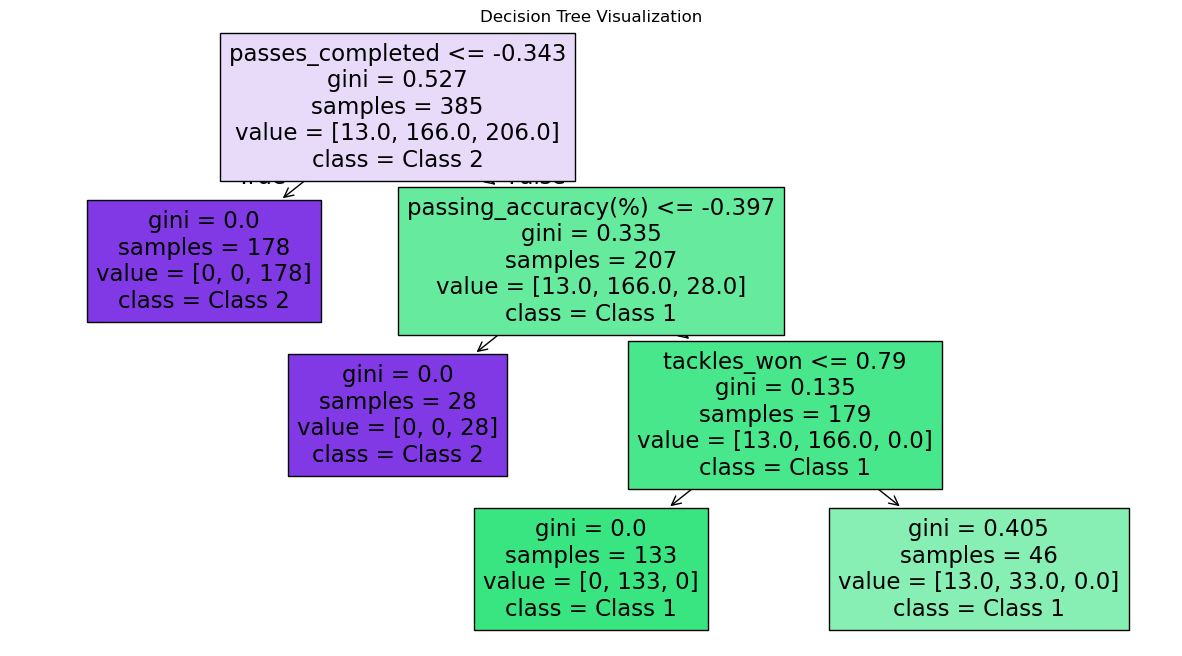

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_model.fit(X_train_scaled, y_train)

y_pred = dt_model.predict(X_test_scaled)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Decision Tree Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Decision Tree Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Decision Tree F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

plt.figure(figsize=(15,8))
plot_tree(dt_model, feature_names=features, class_names=['Class 0', 'Class 1', 'Class 2'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

Random Forest Accuracy: 0.9880
Random Forest Precision: 0.9883
Random Forest Recall: 0.9880
Random Forest F1 Score: 0.9868


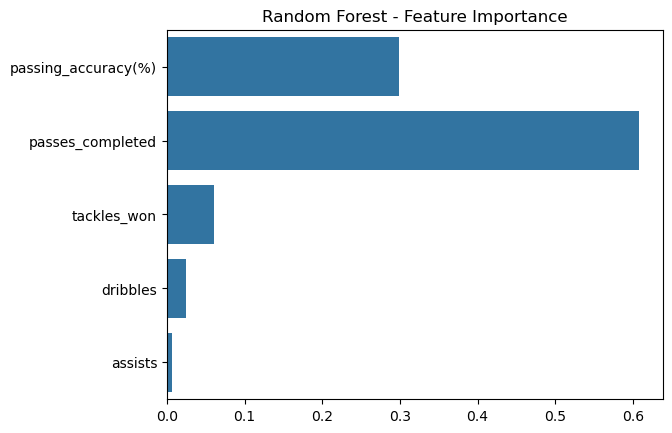

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Precision: {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Random Forest Recall: {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Random Forest F1 Score: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

importances = rf_model.feature_importances_
sns.barplot(x=importances, y=features)
plt.title("Random Forest - Feature Importance")
plt.show()

C:\Users\RePack\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DNN Accuracy: 0.9880


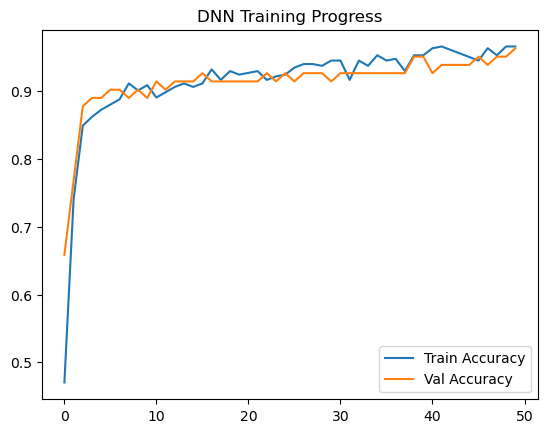

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report

model_dnn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model_dnn.fit(
    X_train_scaled, y_train, 
    epochs=50, 
    batch_size=16, 
    validation_data=(X_val_scaled, y_val),
    verbose=0
)

loss, accuracy = model_dnn.evaluate(X_test_scaled, y_test, verbose=0)
print(f"DNN Accuracy: {accuracy:.4f}")

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('DNN Training Progress')
plt.legend()
plt.show()

C:\Users\RePack\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Accuracy: 0.9036


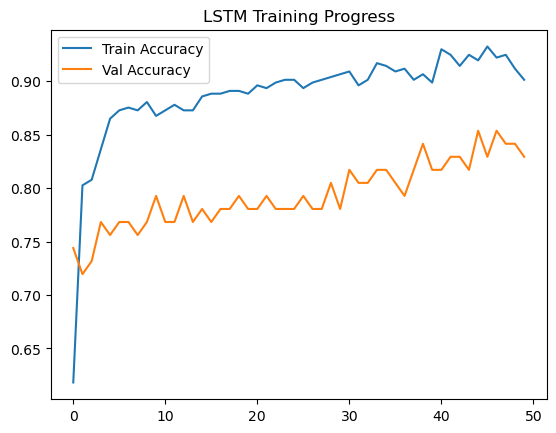

In [9]:
import matplotlib.pyplot as plt
from tensorflow.keras.layers import LSTM

X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_lstm = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

model_lstm = Sequential([
    LSTM(32, input_shape=(X_train_scaled.shape[1], 1)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_lstm = model_lstm.fit(
    X_train_lstm, y_train, 
    epochs=50, 
    batch_size=16, 
    validation_data=(X_val_lstm, y_val), 
    verbose=0
)

loss, accuracy = model_lstm.evaluate(X_test_lstm, y_test, verbose=0)
print(f"LSTM Accuracy: {accuracy:.4f}")

plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Training Progress')
plt.legend()
plt.show()

1D CNN Accuracy: 0.9759


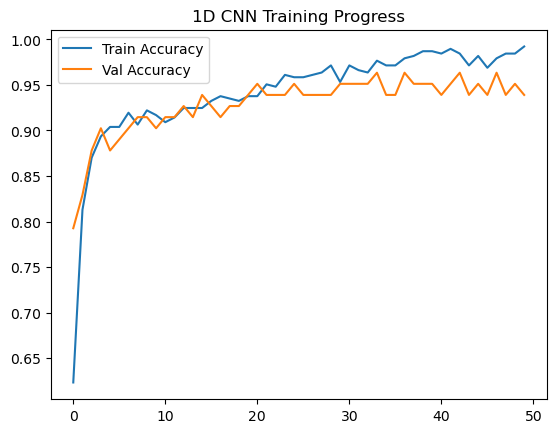

In [11]:
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_cnn = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

model_cnn = Sequential([
    Conv1D(32, kernel_size=2, activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_cnn = model_cnn.fit(
    X_train_cnn, y_train, 
    epochs=50, 
    batch_size=16, 
    validation_data=(X_val_cnn, y_val), 
    verbose=0
)

loss, accuracy = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"1D CNN Accuracy: {accuracy:.4f}")

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('1D CNN Training Progress')
plt.legend()
plt.show()

C:\Users\RePack\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


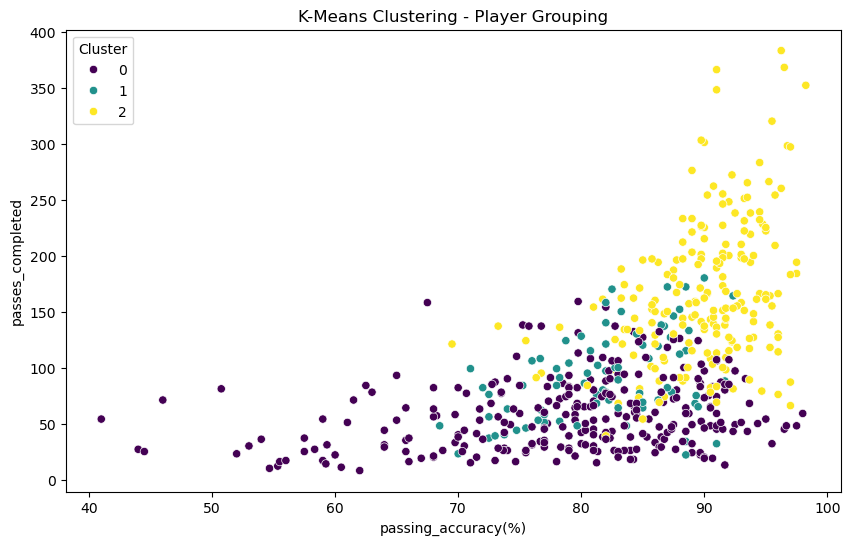

Cluster      0   1    2
Barca_Fit              
0            0   0   16
1           43  33  166
2          231  44   17


In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

X_scaled_full = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled_full)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='passing_accuracy(%)', y='passes_completed', hue='Cluster', palette='viridis')
plt.title('K-Means Clustering - Player Grouping')
plt.show()

print(pd.crosstab(df['Barca_Fit'], df['Cluster']))

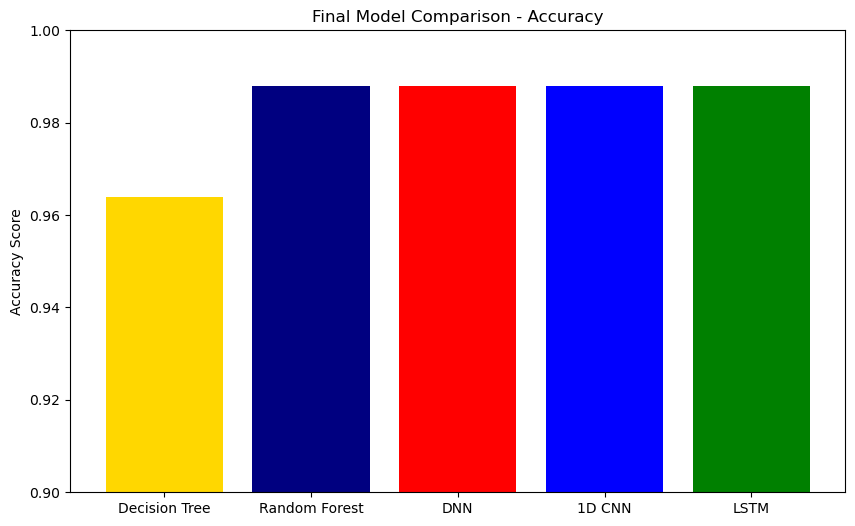

           Model  Accuracy
0  Decision Tree    0.9639
1  Random Forest    0.9880
2            DNN    0.9880
3         1D CNN    0.9880
4           LSTM    0.9880


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

results = {
    'Model': ['Decision Tree', 'Random Forest', 'DNN', '1D CNN', 'LSTM'],
    'Accuracy': [0.9639, 0.9880, 0.9880, 0.9880, 0.9880]
}

df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.bar(df_results['Model'], df_results['Accuracy'], color=['gold', 'navy', 'red', 'blue', 'green'])
plt.ylim(0.9, 1.0)
plt.title('Final Model Comparison - Accuracy')
plt.ylabel('Accuracy Score')
plt.show()

print(df_results)

In [15]:
import pandas as pd

scouting_report = df[df['Barca_Fit'] == 0][['player_name', 'field_position', 'passing_accuracy(%)', 'passes_completed', 'tackles_won']]
scouting_report = scouting_report.sort_values(by='passes_completed', ascending=False)

print("--- Top Targets for FC Barcelona Scouting (Class 0) ---")
print(scouting_report)

df.to_csv('final_barca_scouting_analysis.csv', index=False)

--- Top Targets for FC Barcelona Scouting (Class 0) ---
            player_name field_position  passing_accuracy(%)  passes_completed  \
122          Minjae Kim       Defender                98.25             352.0   
22   Nico Schlotterbeck       Defender                91.00             348.0   
43      Dayot Upamecano       Defender                97.00             297.0   
133      Atakan Karazor     Midfielder                95.25             266.0   
38      Ladislav Krejčí       Defender                91.50             255.0   
10        Ryan Flamingo       Defender                94.50             239.0   
34       Marten de Roon     Midfielder                93.75             238.0   
64     Nicolás Otamendi       Defender                95.00             222.0   
65         Joel Ordoñez       Defender                93.75             219.0   
189        Granit Xhaka     Midfielder                91.75             210.0   
104     Youssouf Fofana     Midfielder               

In [18]:
import pandas as pd

players = pd.read_csv('players_data.csv')
dist = pd.read_csv('distribution_data.csv')
defend = pd.read_csv('defending_data.csv')
key_stats = pd.read_csv('key_stats_data.csv')
attack = pd.read_csv('attacking_data.csv')
teams = pd.read_csv('teams_data.csv')

df = pd.merge(players[['id_player', 'player_name', 'field_position', 'id_team']], dist[['id_player', 'passing_accuracy(%)', 'passes_completed']], on='id_player', how='inner')
df = pd.merge(df, defend[['id_player', 'tackles_won']], on='id_player', how='inner')
df = pd.merge(df, key_stats[['id_player', 'minutes_played']], on='id_player', how='inner')
df = pd.merge(df, attack[['id_player', 'dribbles', 'assists']], on='id_player', how='inner')

df = pd.merge(df, teams[['team_id', 'team']], left_on='id_team', right_on='team_id', how='left')

df = df[df['minutes_played'] >= 90]
df = df.fillna(0)

def calculate_barca_fit(row):
    acc = row['passing_accuracy(%)']
    volume = row['passes_completed']
    tkl = row['tackles_won']
    if acc >= 90 and volume >= 150 and tkl >= 3:
        return 0
    elif acc >= 80 and volume >= 80:
        return 1
    else:
        return 2

df['Barca_Fit'] = df.apply(calculate_barca_fit, axis=1)

scouting_report = df[df['Barca_Fit'] == 0][['player_name', 'team', 'field_position', 'passing_accuracy(%)', 'passes_completed', 'tackles_won']]
scouting_report = scouting_report.sort_values(by='passes_completed', ascending=False)

print(scouting_report)

            player_name                 team field_position  \
122          Minjae Kim    FC Bayern München       Defender   
22   Nico Schlotterbeck    Borussia Dortmund       Defender   
43      Dayot Upamecano    FC Bayern München       Defender   
133      Atakan Karazor        VfB Stuttgart     Midfielder   
38      Ladislav Krejčí            Girona FC       Defender   
10        Ryan Flamingo        PSV Eindhoven       Defender   
34       Marten de Roon          Atalanta BC     Midfielder   
64     Nicolás Otamendi           SL Benfica       Defender   
65         Joel Ordoñez       Club Brugge KV       Defender   
189        Granit Xhaka  Bayer 04 Leverkusen     Midfielder   
104     Youssouf Fofana             AC Milan     Midfielder   
222  José María Giménez   Atlético de Madrid       Defender   
92      Anthony Rouault        VfB Stuttgart       Defender   
53       Valeriy Bondar  FC Shakhtar Donetsk       Defender   
245       Denis Zakaria            AS Monaco     Midfie